In [ ]:
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
import src.ModelUtils as mu

### Choose model between base MultimodalSDM and the variant model that doesn't use satellite images by commenting/uncommenting following import

In [ ]:
from src.MultimodalSDM import multimodal_SDM, load_model, save_model, delete_model, name
# from src.MultimodalSDM_noSat import multimodal_SDM, load_model, save_model, delete_model, name

In [74]:
print(f"Selected model: {name}")

Selected model: multimodal_SDM_base


### Load test dataset and retrieve one sample

In [75]:
device = 'cpu'
dl_test = mu.load_dataloader(batch_size=1, split='test')
sample = iter(dl_test).__next__()

### Load model

* Get weights [here](https://e.pcloud.link/publink/show?code=XZvhoNZIkthPGkkBxm4PIMeEnI3hbfXqnf7) (MultimodalSDM model)
* Get weights [here](https://e.pcloud.link/publink/show?code=XZGuoNZImWAxCbQaTBhE3126kvyWjL08x5V) (MultimodalSDM_noSat model)

In [76]:
model = multimodal_SDM()

if name == "multimodal_SDM_base":
    weights_file = glob.glob("**/70_AUC=0.846.pth", recursive=True)[0] # MultimodalSDM
elif name == "multimodal_SDM_no-sat":
    weights_file = glob.glob("**/53_AUC=0.849.pth", recursive=True)[0] # MultimodalSDM_noSat
else:
    print("Model not known")

stateDict = torch.load(open(weights_file, 'rb'), map_location='cpu')
model.load_state_dict(stateDict)

<All keys matched successfully>

### Model inference

In [77]:
pred = model(sample)[0].detach().numpy()

### Visualize

In [78]:
true = sample['species_labels'][0]

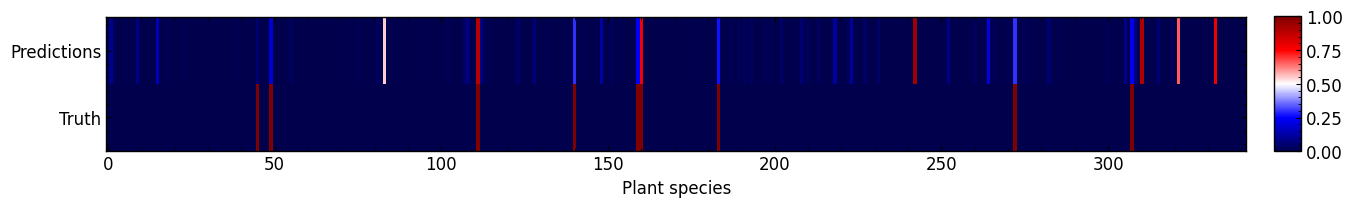

In [79]:
fig, ax = plt.subplots(figsize=(15,3))
im = ax.imshow([pred, true], vmin=0, vmax=1, cmap="seismic", interpolation="none")
ax.set_aspect(20)
ax.set_xlabel("Plant species")
ax.set_yticks([0,1], ["Predictions", "Truth"])
fig.colorbar(im, aspect=5, shrink=0.5, pad=0.02)
fig.tight_layout()
plt.show()